In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset.  ##diccionario de variables

In [7]:
#cargar los datos
data=fetch_california_housing() #datos previamente limpios
X=data.data
print(X)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [6]:
y=data.target
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [14]:
X.shape

(20640, 8)

#normalizar (dejar todas las variables en una misma escala de valores)
https://scikit-learn.org/stable/modules/preprocessing.html

In [8]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

array([[ 2.34476576,  0.98214266,  0.62855945, ..., -0.04959654,
         1.05254828, -1.32783522],
       [ 2.33223796, -0.60701891,  0.32704136, ..., -0.09251223,
         1.04318455, -1.32284391],
       [ 1.7826994 ,  1.85618152,  1.15562047, ..., -0.02584253,
         1.03850269, -1.33282653],
       ...,
       [-1.14259331, -0.92485123, -0.09031802, ..., -0.0717345 ,
         1.77823747, -0.8237132 ],
       [-1.05458292, -0.84539315, -0.04021111, ..., -0.09122515,
         1.77823747, -0.87362627],
       [-0.78012947, -1.00430931, -0.07044252, ..., -0.04368215,
         1.75014627, -0.83369581]])

#Validación cruzada (dividir conjunto de datos inicial)

In [17]:
# 1. método de retención
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

#Crear el modelos de regresión lineal
https://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares

In [18]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [30]:
model.score(X_train,y_train) #R2

0.6125511913966952

In [22]:
model.coef_

array([ 0.85238169,  0.12238224, -0.30511591,  0.37113188, -0.00229841,
       -0.03662363, -0.89663505, -0.86892682])

In [23]:
model.intercept_

np.float64(2.067862309508389)

precio=2.06+0.85X1+0.12X2+....-0.87X8

### Evaluar el modelo con datos de prueba (X_test)

In [24]:
model.score(X_test,y_test)

0.5757877060324511

#Crear el modelo de Arból de decisión
https://scikit-learn.org/stable/auto_examples/tree/plot_tree_regression.html#sphx-glr-auto-examples-tree-plot-tree-regression-py

In [25]:
from sklearn.tree import DecisionTreeRegressor
model_tree=DecisionTreeRegressor()
model_tree.fit(X_train,y_train)

DecisionTreeRegressor()

In [28]:
model_tree.score(X_train,y_train)

1.0

In [29]:
model_tree.score(X_test,y_test)

0.627504383562778

# Crear modelo Bosque aleatorio
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor

In [31]:
from sklearn.ensemble import RandomForestRegressor
model_rf=RandomForestRegressor()
model_rf.fit(X_train,y_train)

RandomForestRegressor()

In [32]:
model_rf.score(X_train,y_train)

0.9739523072640753

In [33]:
model_rf.score(X_test,y_test)

0.806654038616226

# Validación cruzada K-fold
https://www.kaggle.com/code/satishgunjal/tutorial-k-fold-cross-validation

In [39]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=5, random_state=42, shuffle=True)
kf

KFold(n_splits=5, random_state=42, shuffle=True)

In [45]:
# Obtenemos los R² para cada fold para el model RL
scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')
scores

array([0.60970239, 0.60411343, 0.6354319 , 0.60076148, 0.60727452])

In [46]:
# 7. Calcule el promedio de R²
promedio_r2 = np.mean(scores)
desviacion_r2 = np.std(scores)
print(promedio_r2,desviacion_r2)

0.611456745810643 0.012358719496266638


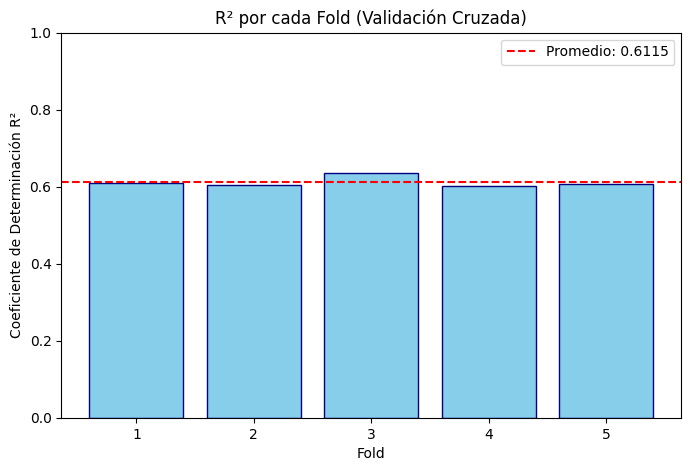

In [47]:
# 6. Graficar los scores de R² de cada fold
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), scores, color='skyblue', edgecolor='navy')
plt.axhline(y=np.mean(scores), color='red', linestyle='--', label=f'Promedio: {np.mean(scores):.4f}')
plt.title('R² por cada Fold (Validación Cruzada)')
plt.xlabel('Fold')
plt.ylabel('Coeficiente de Determinación R²')
plt.legend()
plt.ylim(0, 1) # El R² suele estar entre 0 y 1
plt.show()